In [32]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="muted", color_codes=True)
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


pd.set_option('display.max_rows', None)

filepath = r"C:\Users\felix\ames_housing-ml\data\AmesHousing.csv"
df =pd.read_csv(filepath)
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(exclude="object").columns.tolist()

df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df[categorical_cols].mode().iloc[0])
df.head()
df.tail()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0,7937,Pave,Grvl,IR1,Lvl,...,0,Ex,GdPrv,Shed,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,68.0,8885,Pave,Grvl,IR1,Low,...,0,Ex,MnPrv,Shed,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,Grvl,Reg,Lvl,...,0,Ex,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,Grvl,Reg,Lvl,...,0,Ex,MnPrv,Shed,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0,9627,Pave,Grvl,Reg,Lvl,...,0,Ex,MnPrv,Shed,0,11,2006,WD,Normal,188000


In [33]:
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [34]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [35]:
X = df.copy()
y = X.pop("SalePrice")
X = X.drop(columns=["Order", "PID"], errors="ignore")
X.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,141.0,31770,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,0,0,Ex,MnPrv,Shed,0,5,2010,WD,Normal
1,20,RH,80.0,11622,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,120,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal
2,20,RL,81.0,14267,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,0,0,Ex,MnPrv,Gar2,12500,6,2010,WD,Normal
3,20,RL,93.0,11160,Pave,Grvl,Reg,Lvl,AllPub,Corner,...,0,0,Ex,MnPrv,Shed,0,4,2010,WD,Normal
4,60,RL,74.0,13830,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal


In [36]:
mi_scores = make_mi_scores(X, y)
print(mi_scores.head(15))

Overall Qual      0.586889
Neighborhood      0.575451
Lot Area          0.488880
Year Built        0.440015
Gr Liv Area       0.438265
Garage Area       0.419132
Total Bsmt SF     0.392089
Garage Cars       0.386663
Bsmt Qual         0.360831
1st Flr SF        0.354010
Garage Yr Blt     0.336698
Kitchen Qual      0.333100
Exter Qual        0.329214
Year Remod/Add    0.315388
MS SubClass       0.301140
Name: MI Scores, dtype: float64


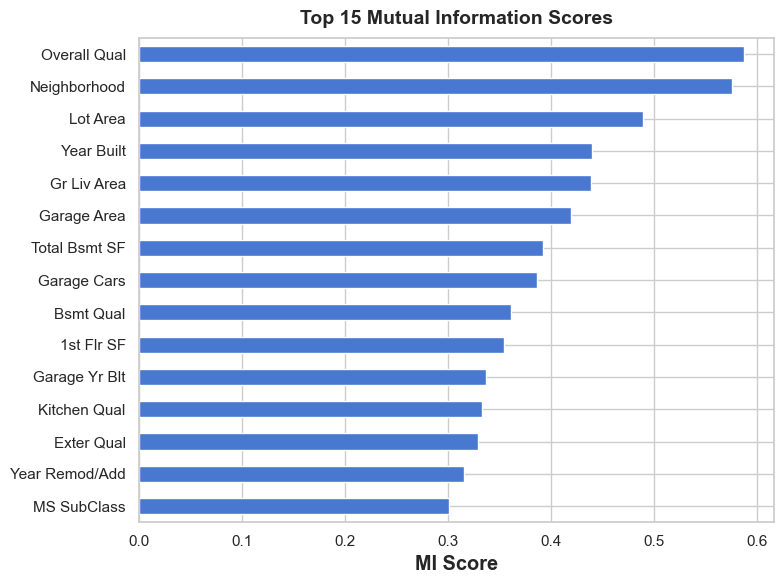

In [37]:
plt.figure(figsize=(8,6))
mi_scores.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Mutual Information Scores")
plt.xlabel("MI Score")
plt.show()